# RNN Memory Basics

## Goal
Turn the original handwritten RNN notes into a small, runnable notebook that explains why sequence order matters and why gated recurrent units help preserve useful context.

## What This Covers
- sequence windows for time-ordered data
- a tiny vanilla recurrent update
- a simple gating demo inspired by LSTM and GRU behavior

## Limits
This notebook focuses on intuition with NumPy rather than full TensorFlow training. The source notebook was mostly conceptual notes, so the cleaned version stays lightweight and executable.

Sequence length: 160
Windowed samples: (148, 12)
Next-step targets: (148,)
First input window: [0.15  0.259 0.349 0.421 0.479 0.528 0.573 0.619 0.669 0.726 0.789 0.857]
First target: 0.925


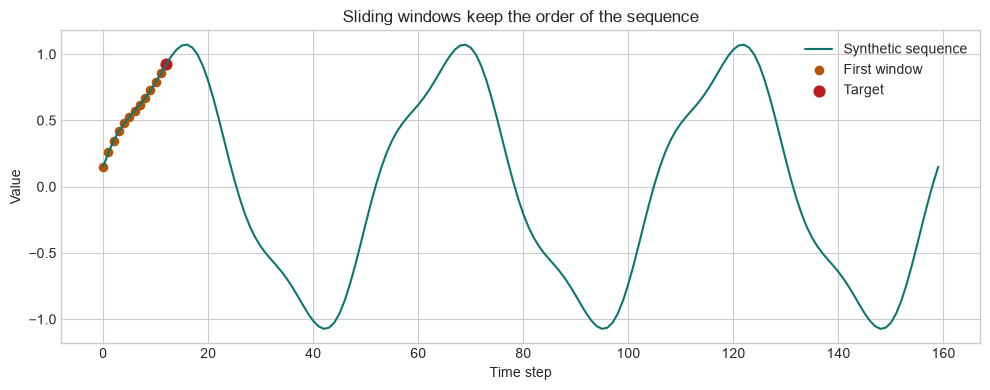

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

steps = np.linspace(0, 6 * np.pi, 160)
series = np.sin(steps) + 0.15 * np.cos(3 * steps)

def make_windows(values, window_size):
    X, y = [], []
    for start in range(len(values) - window_size):
        X.append(values[start:start + window_size])
        y.append(values[start + window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = make_windows(series, window_size)

print('Sequence length:', len(series))
print('Windowed samples:', X.shape)
print('Next-step targets:', y.shape)
print('First input window:', np.round(X[0], 3))
print('First target:', round(float(y[0]), 3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(series, label='Synthetic sequence', color='#0f766e')
ax.scatter(np.arange(window_size), X[0], color='#b45309', s=35, label='First window')
ax.scatter(window_size, y[0], color='#b91c1c', s=60, label='Target')
ax.set_title('Sliding windows keep the order of the sequence')
ax.set_xlabel('Time step')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

## Vanilla Recurrence
A basic recurrent unit mixes the current value with the previous hidden state. The hidden state acts like a compressed memory of what the model has seen so far.

Sample window values: [0.669 0.726 0.789 0.857 0.925 0.986 1.036 1.066 1.072 1.049 0.995 0.91 ]
Hidden states: [0.539 0.714 0.775 0.808 0.832 0.852 0.866 0.874 0.876 0.871 0.858 0.835]


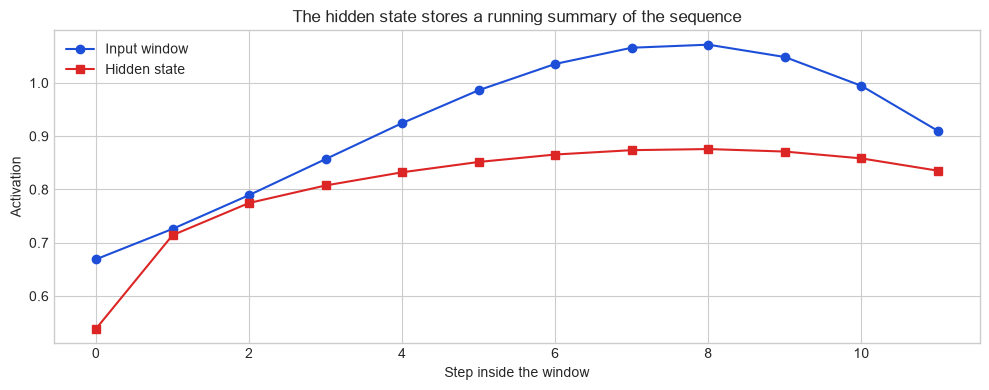

In [2]:
sample = X[8]

def simple_rnn_rollout(sequence, wx=0.9, wh=0.45):
    hidden = 0.0
    states = []
    for value in sequence:
        hidden = np.tanh(wx * value + wh * hidden)
        states.append(hidden)
    return np.array(states)

hidden_states = simple_rnn_rollout(sample)
print('Sample window values:', np.round(sample, 3))
print('Hidden states:', np.round(hidden_states, 3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample, marker='o', label='Input window', color='#1d4ed8')
ax.plot(hidden_states, marker='s', label='Hidden state', color='#dc2626')
ax.set_title('The hidden state stores a running summary of the sequence')
ax.set_xlabel('Step inside the window')
ax.set_ylabel('Activation')
ax.legend()
plt.tight_layout()
plt.show()

## Why Gating Helps
A plain recurrent update can forget older signals quickly. LSTM and GRU layers introduce gates that decide how much past information to keep or overwrite.

Final plain-state magnitude: 0.0
Final gated-state magnitude: 0.0033


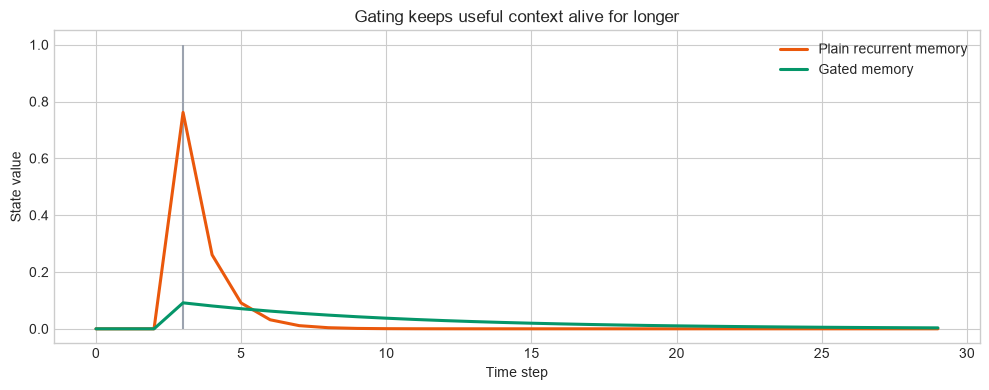

In [3]:
impulse = np.zeros(30)
impulse[3] = 1.0

def plain_memory(signal, wx=1.0, wh=0.35):
    hidden = 0.0
    values = []
    for x_t in signal:
        hidden = np.tanh(wx * x_t + wh * hidden)
        values.append(hidden)
    return np.array(values)

def gated_memory(signal, candidate_weight=1.0, keep_gate=0.88):
    hidden = 0.0
    values = []
    for x_t in signal:
        candidate = np.tanh(candidate_weight * x_t)
        hidden = keep_gate * hidden + (1 - keep_gate) * candidate
        values.append(hidden)
    return np.array(values)

plain_track = plain_memory(impulse)
gated_track = gated_memory(impulse)

print('Final plain-state magnitude:', round(float(abs(plain_track[-1])), 4))
print('Final gated-state magnitude:', round(float(abs(gated_track[-1])), 4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(np.arange(len(impulse)), impulse, linefmt='#9ca3af', markerfmt=' ', basefmt=' ')
ax.plot(plain_track, label='Plain recurrent memory', linewidth=2.2, color='#ea580c')
ax.plot(gated_track, label='Gated memory', linewidth=2.2, color='#059669')
ax.set_title('Gating keeps useful context alive for longer')
ax.set_xlabel('Time step')
ax.set_ylabel('State value')
ax.legend()
plt.tight_layout()
plt.show()

## What I Learned
- RNN inputs are not just feature vectors; they are ordered chunks of history.
- The hidden state gives the model a compact summary of earlier steps.
- Gated updates are useful because they slow down forgetting when old context still matters.